## Notebook 7 - Anomaly Detection & Weekly Backtesting

In [1]:
#Imports
import pandas as pd
import numpy as np

# 1. LOAD RECONCILED PREDICTIONS

df = pd.read_csv("reconciled_predictions.csv", parse_dates=['Date'])
print("Shape:", df.shape)
df.head()


Shape: (844338, 7)


,Store,Date,Sales,pred,StoreType,store_scale,reconciled_pred
0,1,2013-01-02,5530,5509.712206,c,1.000202,5510.826715
1,1,2013-01-03,4327,4323.122422,c,1.000202,4323.996907
2,1,2013-01-04,4486,4503.223863,c,1.000202,4504.134779
3,1,2013-01-05,4997,5001.119757,c,1.000202,5002.131388
4,1,2013-01-07,7176,7155.456988,c,1.000202,7156.904400


In [2]:
# 2. ERROR CALCULATION

df['error']     = df['Sales'] - df['reconciled_pred']
df['abs_error'] = np.abs(df['error'])
df['pct_error'] = df['abs_error'] / df['Sales'].clip(lower=1)   # FIX: normalised error


In [3]:
# 3. PER-STORE ROLLING ANOMALY THRESHOLD

cutoff_date = "2015-06-01"
train_mask = df['Date'] < cutoff_date

# Compute rolling 99th percentile on pct_error within training period
df_train = df[train_mask].copy()
df_train['rolling_threshold'] = df_train.groupby('Store')['pct_error'].transform(
    lambda x: x.rolling(28, min_periods=1).quantile(0.99)
)

# Keep threshold for merging
threshold_df = df_train[['Store', 'Date', 'rolling_threshold']]

# Merge (training dates get thresholds, test dates get NaN)
df = df.merge(threshold_df, on=['Store', 'Date'], how='left')

# Forward fill thresholds for test dates (use last known per store)
df['threshold'] = df.groupby('Store')['rolling_threshold'].ffill()

# Fallback for any store without a threshold
global_threshold = df['pct_error'].quantile(0.995)
df['threshold'] = df['threshold'].fillna(global_threshold)

# Flag anomalies
df['is_anomaly'] = df['pct_error'] > df['threshold']

print("Total anomalies:", df['is_anomaly'].sum())

Total anomalies: 32618


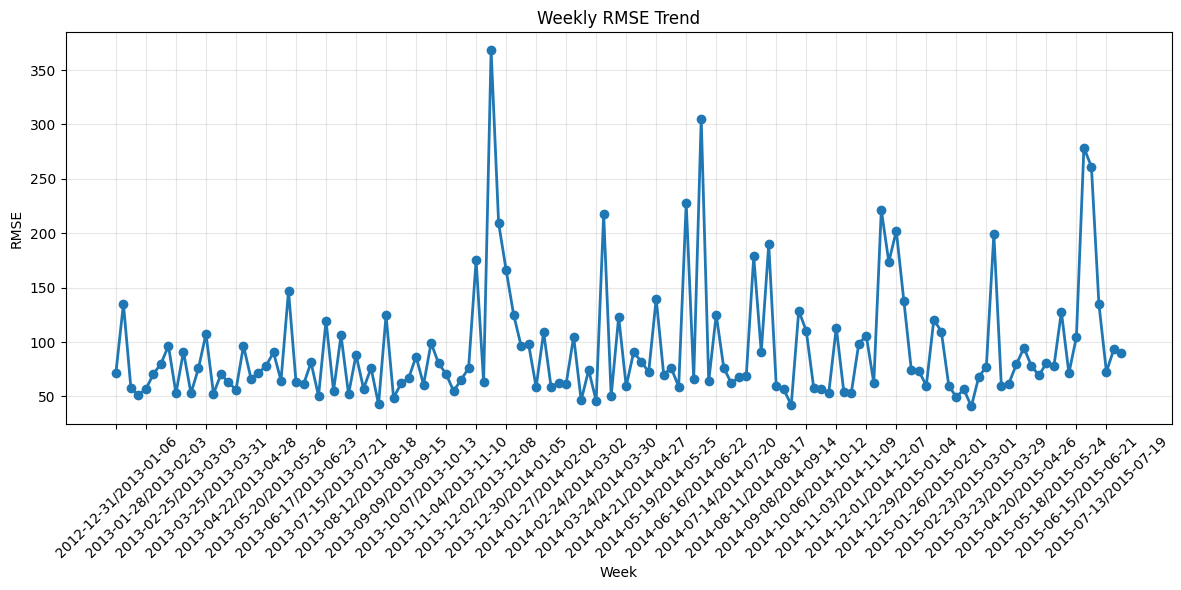

In [4]:

# GRAPH 1: WEEKLY RMSE TREND


df['Week'] = df['Date'].dt.to_period('W')

weekly_rmse = df.groupby('Week', group_keys=False).apply(
    lambda x: np.sqrt(np.mean((x['Sales'] - x['reconciled_pred'])**2)), include_groups=False
).reset_index(name='RMSE')

weekly_rmse['Week'] = weekly_rmse['Week'].astype(str)


# WEEKLY RMSE PLOT


import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(weekly_rmse['Week'], weekly_rmse['RMSE'],
         marker='o', linewidth=2)

# Show only every 4th label
step = 4
plt.xticks(
    ticks=range(0, len(weekly_rmse), step),
    labels=weekly_rmse['Week'][::step],
    rotation=45
)

plt.title("Weekly RMSE Trend")
plt.xlabel("Week")
plt.ylabel("RMSE")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

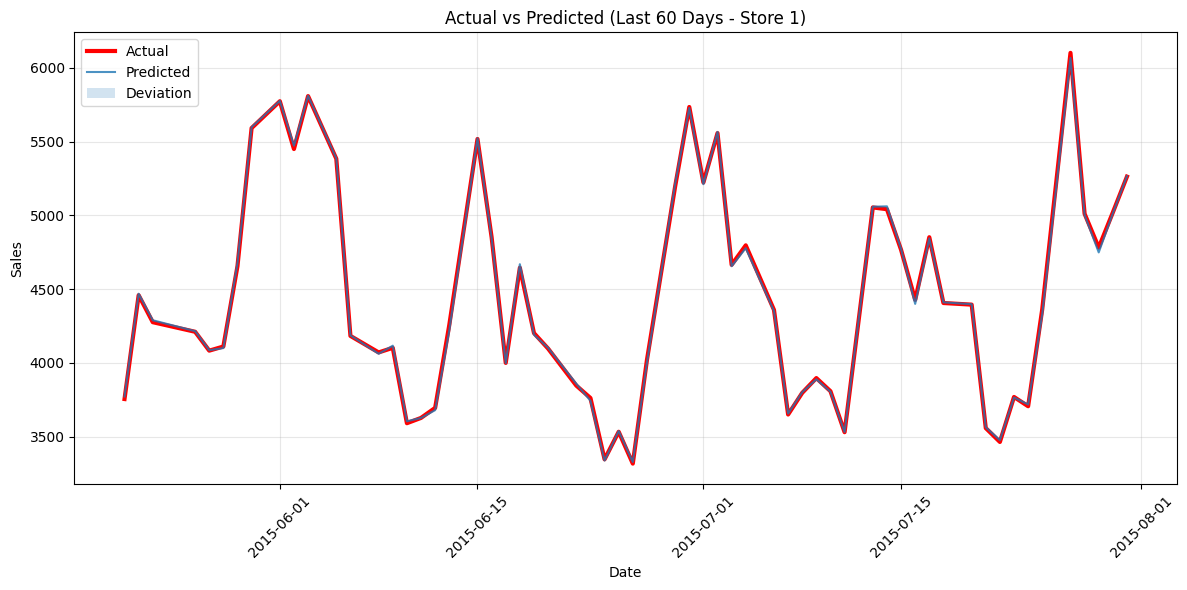

In [5]:
# GRAPH 2: ACTUAL vs PREDICTED


sample_store = df['Store'].iloc[0]
sample_df = df[df['Store'] == sample_store].copy()

sample_df = sample_df.sort_values('Date').tail(60)

plt.figure(figsize=(12,6))

# Actual (thick)
plt.plot(sample_df['Date'], sample_df['Sales'],
         linewidth=3, color='red', label='Actual')

# Predicted (thin)
plt.plot(sample_df['Date'], sample_df['reconciled_pred'],
         linewidth=1.5, alpha=0.8, label='Predicted')

# Highlight difference
plt.fill_between(sample_df['Date'],
                 sample_df['Sales'],
                 sample_df['reconciled_pred'],
                 alpha=0.2, label='Deviation')

plt.title(f"Actual vs Predicted (Last 60 Days - Store {sample_store})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# 4. VIEW ANOMALY SAMPLE

anomaly_sample = df[df['is_anomaly']].head(10)
print("Sample anomalies:")
print(anomaly_sample[['Store','Date','Sales','reconciled_pred','abs_error','pct_error']])


Sample anomalies:
     Store       Date  Sales  reconciled_pred  abs_error  pct_error
2        1 2013-01-04   4486      4504.134779  18.134779   0.004043
6        1 2013-01-09   5471      5507.125355  36.125355   0.006603
51       1 2013-03-02   5350      5372.355234  22.355234   0.004179
65       1 2013-03-19   6563      6528.512795  34.487205   0.005255
77       1 2013-04-04   4293      4319.469068  26.469068   0.006166
89       1 2013-04-18   2952      2933.486743  18.513257   0.006271
115      1 2013-05-22   3559      3524.115180  34.884820   0.009802
154      1 2013-07-08   4475      4434.204103  40.795897   0.009116
187      1 2013-08-15   4575      4533.488375  41.511625   0.009074
240      1 2013-10-17   3223      3177.281439  45.718561   0.014185


In [7]:
# 5. WEEKLY BACKTESTING (per-store then average)

df['Week'] = df['Date'].dt.to_period('W')

store_weekly_rmse = df.groupby(['Store','Week']).apply(
    lambda x: np.sqrt(np.mean((x['Sales'] - x['reconciled_pred'])**2)),
    include_groups=False
).reset_index(name='RMSE')

weekly_avg_rmse = store_weekly_rmse.groupby('Week')['RMSE'].mean().reset_index()
print("Weekly Average RMSE (across stores):")
print(weekly_avg_rmse)


Weekly Average RMSE (across stores):
                      Week       RMSE
0    2012-12-31/2013-01-06  39.383947
1    2013-01-07/2013-01-13  55.027017
2    2013-01-14/2013-01-20  27.710338
3    2013-01-21/2013-01-27  28.192614
4    2013-01-28/2013-02-03  26.178715
..                     ...        ...
130  2015-06-29/2015-07-05  74.845824
131  2015-07-06/2015-07-12  31.783050
132  2015-07-13/2015-07-19  34.678132
133  2015-07-20/2015-07-26  33.323031
134  2015-07-27/2015-08-02  38.570955

[135 rows x 2 columns]


In [8]:
# 6. SAVE WEEKLY PERFORMANCE

weekly_avg_rmse.to_csv("weekly_performance.csv", index=False)
print("Saved: weekly_performance.csv")


Saved: weekly_performance.csv


In [9]:
# 7. TOP 5 STORES WITH MOST ANOMALIES

top_anomaly_stores = df[df['is_anomaly']]['Store'].value_counts().head(5)
print("Top 5 stores with most anomalies:")
print(top_anomaly_stores)


Top 5 stores with most anomalies:
Store
562     53
616     49
1063    48
1097    48
733     47
Name: count, dtype: int64


In [10]:
# 8. ANOMALIES PER WEEK

weekly_anomalies = df[df['is_anomaly']].groupby('Week').size()
print("Anomalies per week:")
print(weekly_anomalies)


Anomalies per week:
Week
2012-12-31/2013-01-06    788
2013-01-07/2013-01-13    641
2013-01-14/2013-01-20    393
2013-01-21/2013-01-27    110
2013-01-28/2013-02-03    104
                        ... 
2015-06-29/2015-07-05    466
2015-07-06/2015-07-12    283
2015-07-13/2015-07-19    201
2015-07-20/2015-07-26    387
2015-07-27/2015-08-02    161
Freq: W-SUN, Length: 135, dtype: int64


In [11]:
# 9. BUSINESS OUTPUT: ANOMALIES BY STORETYPE CATEGORY

store_info = pd.read_csv("store.csv")[['Store','StoreType']]

if 'StoreType' in df.columns:
    df = df.drop(columns=['StoreType'])

df = df.merge(store_info, on='Store', how='left')

anomaly_by_category = df[df['is_anomaly']].groupby('StoreType').size().sort_values(ascending=False)
print("Top categories at stockout risk (by anomaly count):")
print(anomaly_by_category)


Top categories at stockout risk (by anomaly count):
StoreType
a    17627
d    10002
c     4348
b      641
dtype: int64


In [12]:
# 10. DECISION-READY TABLE: Top 5 stores — recent 4 weeks

last_4_weeks = df['Week'].max() - 4
recent_anomalies = df[(df['is_anomaly']) & (df['Week'] > last_4_weeks)]
top_5_risk = recent_anomalies['Store'].value_counts().head(5).reset_index()
top_5_risk.columns = ['Store', 'Anomaly_Count_Last_4_Weeks']

print("Top 5 stores at stockout risk:")
print(top_5_risk)

top_5_risk.to_csv("top_5_stockout_risk.csv", index=False)
print("Saved: top_5_stockout_risk.csv")


Top 5 stores at stockout risk:
   Store  Anomaly_Count_Last_4_Weeks
0   1063                          10
1    562                          10
2    642                           9
3    669                           8
4    473                           7
Saved: top_5_stockout_risk.csv
